# Gurobi scaling analysis

In this notebook we solve the solomon instances timing each run.
We compare some Solomon families to see how the customer layout and the time-window change

## Imports

In [1]:
import sys
import os

root = os.path.dirname(os.getcwd())
sys.path.append(root)

import time
import matplotlib.pyplot as plt

from cvrptw.parser import parse_solomon
from cvrptw.model import Instance
from cvrptw.solvers.gurobi_solver import solve

## A sub-instance of the first n customers


In [2]:
def n_customers(instance, n):
    return Instance(instance.name, instance.vehicle_capacity, instance.nodes[:n + 1], instance.num_vehicles)

## Run the experiment

One representative instance per Solomon family:
- **c1 / c2**: clustered locations (tight / wide windows)
- **r1 / r2**: random locations (tight / wide windows)
- **rc1 / rc2**: mixed locations (tight / wide windows)


In [3]:
families = ['c101', 'c201', 'r101', 'r201', 'rc101', 'rc201']
sizes = list(range(10, 81, 10)) 

results = {}
for name in families:
    data = parse_solomon(f'../data/solomon/{name}.txt')
    xs = []
    ys = []
    for size in sizes:
        sub = n_customers(data, size)
        start = time.perf_counter()
        solve(sub)
        iteration_time = time.perf_counter() - start
        xs.append(size)
        ys.append(iteration_time)
        print(f'{name}  n={size}  time={iteration_time}s')
    results[name] = (xs, ys)

c101  n=10  time=0.9565572999999858s
c101  n=20  time=0.16258500001276843s
c101  n=30  time=0.45700660000147764s
c101  n=40  time=0.8317374999896856s
c101  n=50  time=1.5956539000035264s
c101  n=60  time=1.5817321999929845s
c101  n=70  time=2.345896399987396s
c101  n=80  time=3.0908635999949183s
c201  n=10  time=0.07430550000572111s
c201  n=20  time=0.36025420000078157s
c201  n=30  time=0.3309307000017725s
c201  n=40  time=0.7185526000102982s
c201  n=50  time=1.0301093000016408s
c201  n=60  time=1.5754014999984065s
c201  n=70  time=2.005130299992743s
c201  n=80  time=2.560453800004325s
r101  n=10  time=0.0752546000003349s
r101  n=20  time=0.15437350000138395s
r101  n=30  time=0.37306110000645276s
r101  n=40  time=0.8410727000009501s
r101  n=50  time=1.192531799999415s
r101  n=60  time=1.6849627000046894s
r101  n=70  time=2.2889086000068346s
r101  n=80  time=3.086641800007783s
r201  n=10  time=0.08361820000573061s
r201  n=20  time=0.1498076999996556s
r201  n=30  time=0.5617155999934766s

## Plot the evolution

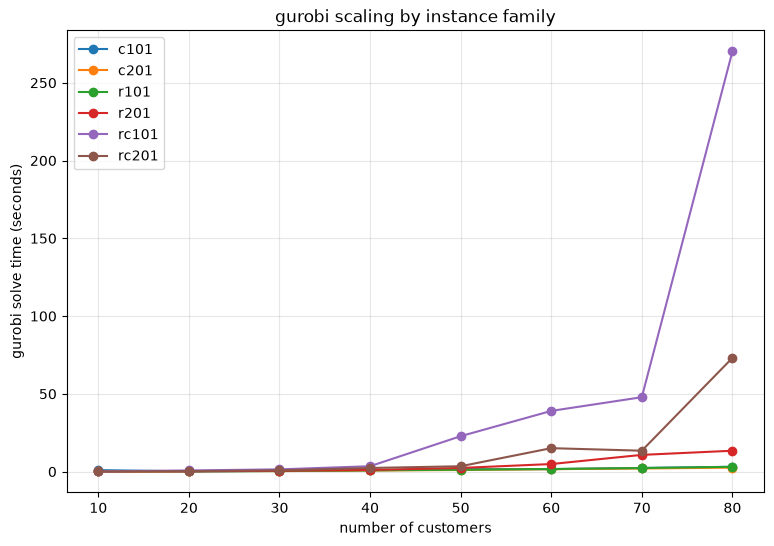

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, (xs, ys) in results.items():
    ax.plot(xs, ys, marker='o', label=name)

ax.set_xlabel('number of customers')
ax.set_ylabel('gurobi solve time (seconds)')
ax.set_title('gurobi scaling by instance family')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Brief conclusion

As a first step I chose Gurobi, since it is the solver I already knew from class. I knew from the beginning that writing the CVRPTW as a closed problem with a single global optimum and then searching for that optimum wasnt the most efficeint solution. This solution would probably scale very fast making it unsustainable for real situations where a single city can have tens of thousands of customers. Even so, it was a useful first approach as it let me get to know the problem and see with my own results why this approach becomes infeasible as the number of customers grows.

To prove this point we can see by looking at the graph how almost all the families stay flat and close to zero up to 80 customers so in those cases Gurobi still solves quickly. The clear exception is rc101 which stays low until 70 customers and then jumps to around 270 seconds at 80. We can see how this explotion indicates probably an exponential time scaling, which is infeasible for a real life scenario.